## Build a Basic Chatbot with Langgraph ( Graph API )

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
    
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages : Annotated[list,add_messages] 

graph_builder =  StateGraph[State]

In [3]:
graph_builder

langgraph.graph.state.StateGraph[__main__.State]

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [29]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "meta-llama/llama-4-scout-17b-16e-instruct")

In [30]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 4 Scout 17B', 'release_date': '2025-04-05', 'last_updated': '2025-04-05', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B718840A00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B71B0F0E80>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [31]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [32]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot) # Adding node 

graph_builder.add_edge(START, "llmchatbot") # Adding Edge from start to llmchatbot
graph_builder.add_edge("llmchatbot",END) # Adding Edge from llmchatbot to end

graph = graph_builder.compile() # Compiling the graph

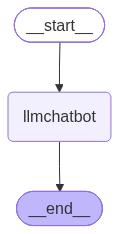

In [33]:
# Visualizing the graph

from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [34]:
graph.invoke({"messages":"Hi"})

NotFoundError: Error code: 404 - {'error': {'message': 'The model `meta-llama/llama-4-scout-17b-16e-instruct` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}